# Supplementary 3: Parameters recovery

In the main text, we have observed that our preference model, describing participants responses as a mixture of forward planning, state-features-dependent preferences and the interaction between the two. This is a rather complex model with preference parameters being estimated as latent variable, and entailing an additional entropy transformation in the interaction term. To establish that despite the complexity of the model, it is still capable of accurately estimate all parameters, we perform a parameter recovery analysis in which we simulate data using the mean parameters recovered from the original data. We then fit the same model to the simulated data. We can then compare the estimated parameters from the simulated data against ground truth to establish the model capacity to identify parameters correctly. 

## Preparing the data
To simulate data and test parameters recovery, we will use the exact same experimental design as provided in the task. 

In [1]:
# General utilities:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Stats
import arviz as az
from scipy.special import expit
from scipy.stats import bernoulli

# Custom packages:
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask

from utilities.models import preference_model

def entropy(p):
    return -p * np.log(p) - (1-p) * np.log(1-p)

# Download the data if needed:
if not os.path.exists('./data/raw_data/all_participants_data.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/data_all_participants_20220215120148.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_data.csv')

# Load the data:
beh_data = pd.read_csv('./data/raw_data/all_participants_data.csv')

# ===================================================================
# Data preprocessing:
# Remove nans:
beh_data = beh_data.dropna()
# Remove timeout:
beh_data = beh_data[beh_data["timeout"] == 0]
# Flip responses: 1 = accept:
beh_data["response"] = (beh_data["response"] == 0).astype(int)
# Make trial 1 based
beh_data["trial"] = beh_data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
beh_data["fc"] = [transitions_costs[row["transition"]][1] for _, row in beh_data.iterrows()]

# Categorical costs regressor
beh_data['is_lc'] = (beh_data['energy_cost'] == 1).astype(int).to_numpy()
beh_data['is_hc'] = (beh_data['energy_cost'] == 2).astype(int).to_numpy()
# Categorical future costs regressor
beh_data['is_lfc'] = (beh_data['fc'] == 1).astype(int).to_numpy()
beh_data['is_hfc'] = (beh_data['fc'] == 2).astype(int).to_numpy()

# Categorical energy regressor:
beh_data['e_is_0'] = (beh_data['energy'] == 0).to_numpy()
beh_data['e_is_1'] = (beh_data['energy'] == 1).to_numpy()
beh_data['e_is_2'] = (beh_data['energy'] == 2).to_numpy()
beh_data['e_is_3'] = (beh_data['energy'] == 3).to_numpy()
beh_data['e_is_4'] = (beh_data['energy'] == 4).to_numpy()
beh_data['e_is_5'] = (beh_data['energy'] == 5).to_numpy()
beh_data['e_is_6'] = (beh_data['energy'] == 6).to_numpy()

# Random effects
subj_idx_raw, subj_labels = pd.factorize(beh_data["vpn"])

# ===================================================================
# Compute decision values:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the data frame:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in beh_data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
beh_data['dv'] = dv_trials

## Simulation
We then retrieve the fitted parameters from the model fitted in the main text and use the mean estimated parameters to simulate the data. 

In [2]:
# Load prefernece model trace:
if os.path.exists("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc"):
    idata_orig = az.from_netcdf("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")
else:
    raise Exception("Make sure to run the index.pynb before running control analyses")

simulated_data = []

# Loop through each participants:
pref_cols = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
# Prepare dictionary to store ground truth parameters:
ground_truth_params = {
    "beta_planning": [],
    "beta_pref": [],
    "beta_interaction": []
}
for i, sub in enumerate(beh_data["vpn"].unique()):
    # ===================================================================
    # Extract experimental design for this subject:
    subject_data = beh_data[beh_data["vpn"] == sub]
    # Extract the preferences regressors:
    prefs_reg = subject_data[pref_cols].to_numpy()
    # Extract the decision values:
    dv = subject_data["dv"].to_numpy()

    # ===================================================================
    # Extract fitted parameters for this subject:
    beta_planning = idata_orig.posterior["beta_planning_sub"].mean(dim=["chain", "draw"]).to_numpy()[i, 0]
    beta_pref = idata_orig.posterior["beta_pref_sub"].mean(dim=["chain", "draw"]).to_numpy()[i, :]
    beta_interaction = idata_orig.posterior["beta_interaction_sub"].mean(dim=["chain", "draw"]).to_numpy()[i, 0]

    # ===================================================================
    # Simulate responses following the preference model:
    # Compute preferences
    prefs = (beta_pref * prefs_reg).sum(axis=-1).astype(float)
    # Compute eta:
    eta = beta_planning * dv + prefs + beta_interaction * (dv * entropy(expit(prefs)))
    # Simulate responses:
    resp = bernoulli.rvs(expit(eta))
    # Assemble into a dataframe:
    df = pd.DataFrame({
        "vpn": sub,
        "dv": dv,
        **{col: subject_data[col].to_numpy() for col in pref_cols},
        "response": resp,
    })
    simulated_data.append(df)
    ground_truth_params["beta_planning"].append(beta_planning)
    ground_truth_params["beta_pref"].append(beta_pref)
    ground_truth_params["beta_interaction"].append(beta_interaction)
# Combine into a single dataframe:
simulated_data = pd.concat(simulated_data, ignore_index=True)
    

### Fitting the model and comparing estimated to known parameters
If all goes well, we would expect the estimated parameters to be close to the known ground truth parameters. To make sure that this is the case, we will fit the model and plot the computed parameters against the ground truth

In [3]:
# Fit the model:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/simulation_preferences_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/simulation_preferences_model_trace.nc")
else:
    idata = preference_model(
        y=simulated_data["response"].values,
        decision_values=simulated_data["dv"].values,
        pref_regressors=simulated_data[pref_cols],
        subject_index=subj_idx_raw,
        subject_labels=subj_labels
    )
    # Save the trace to file:
    az.to_netcdf(idata, "./data/bids/limited_energy/derivatives/control_models/simulation_preferences_model_trace.nc")

### Group level parameters
To test whether the model is able to retrieve group level parameters, we can compare the fitted parameters from the simulated to the parameters retrieved by the model from real data.

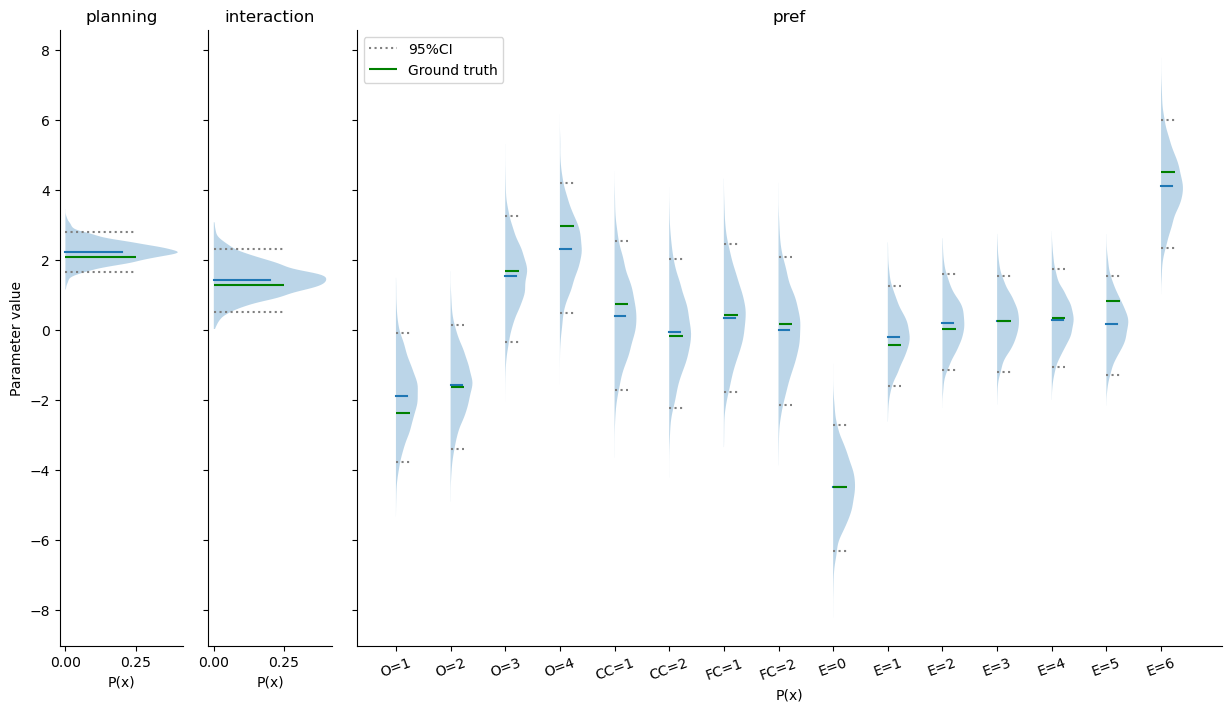

In [ ]:
#| label: suppfig-population_parameter_recovery
#| layout-nrow=20
#| layout-ncol=10
#| fig-cap: "Population level parameters recovery"
# Plot group level parameters:
fig, ax = plt.subplot_mosaic("ABCCCCCC", figsize=(15, 8), sharey=True)
fig_key = ["A", "B", "C"]
for i, param in enumerate(["beta_planning", "beta_interaction", "beta_pref"]):
    # Plot parameters fitted to the simulated data:
    posterior_sim = idata.posterior[param].values.reshape(-1, idata_orig.posterior[param].shape[-1])
    ax[fig_key[i]].violinplot(posterior_sim, positions=range(posterior_sim.shape[-1]), widths=0.8,
                       showmeans=False, showmedians=True,
                       showextrema=False, side="high");
    # Get 95% CI and plot it:
    if len(np.squeeze(posterior_sim).shape) == 1:
        ci = az.hdi(posterior_sim)[0]
        ax[fig_key[i]].hlines(ci, 
                        xmin=[iii for iii in range(posterior_sim.shape[-1])], 
                        xmax=[iii+0.25 for iii in range(posterior_sim.shape[-1])], 
                        color="grey", linestyle=':', label="95%CI")
    else:
        for iii, reg in enumerate(range(posterior_sim.shape[1])):
            ci = az.hdi(posterior_sim[:, reg])
            if iii == 0:
                ax[fig_key[i]].hlines(ci, 
                                    xmin=iii, 
                                    xmax=iii+0.25,
                                    color="grey", linestyle=':', label="95%CI")
            else:
                ax[fig_key[i]].hlines(ci, 
                    xmin=iii, 
                    xmax=iii+0.25,
                    color="grey", linestyle=':')

    # Plot ground truth:
    ax[fig_key[i]].hlines(np.mean(np.array(ground_truth_params[param]), axis=0), 
                          xmin=[iii for iii in range(posterior_sim.shape[-1])], 
                          xmax=[iii+0.25 for iii in range(posterior_sim.shape[-1])], 
                          color="green", label="Ground truth")
    
    ax[fig_key[i]].set_title(param.split("_")[1])
    ax[fig_key[i]].spines[['right', 'top']].set_visible(False)
    ax[fig_key[i]].set_xlabel("P(x)")
    if i == 0:
        ax[fig_key[i]].set_ylabel("Parameter value")
    elif i == 2:
        ax[fig_key[i]].legend()
    if param == "beta_pref":
        ax[fig_key[i]].set_xticks(range(posterior_sim.shape[-1]))
        ax[fig_key[i]].set_xticklabels(["O=1", "O=2", "O=3", "O=4", 
                                       "CC=1", "CC=2", 
                                       "FC=1", "FC=2",
                                       "E=0", "E=1", "E=2", "E=3", "E=4", "E=5", "E=6"], 
                                       rotation=20)
plt.show()

## Single subject parameters:
In addition, we investigate the fit of single subjects parameters against the known ground truth. These should also align:

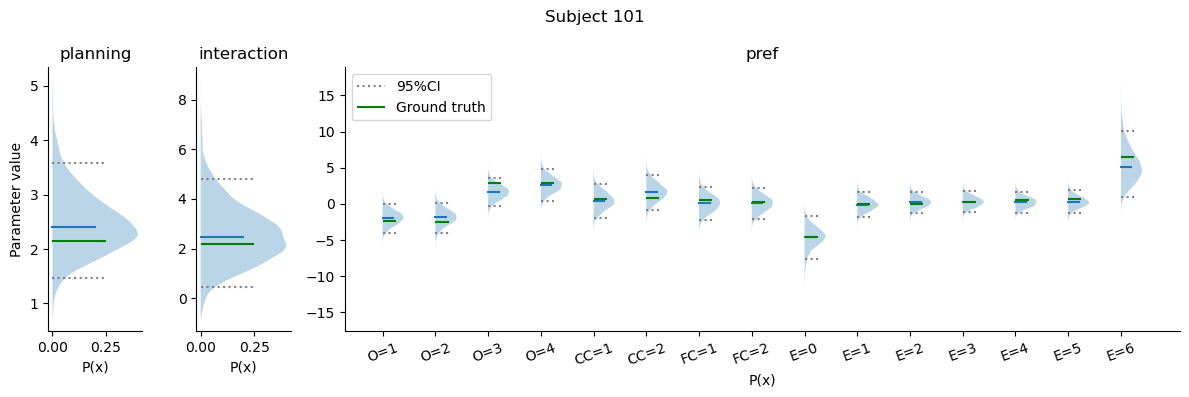

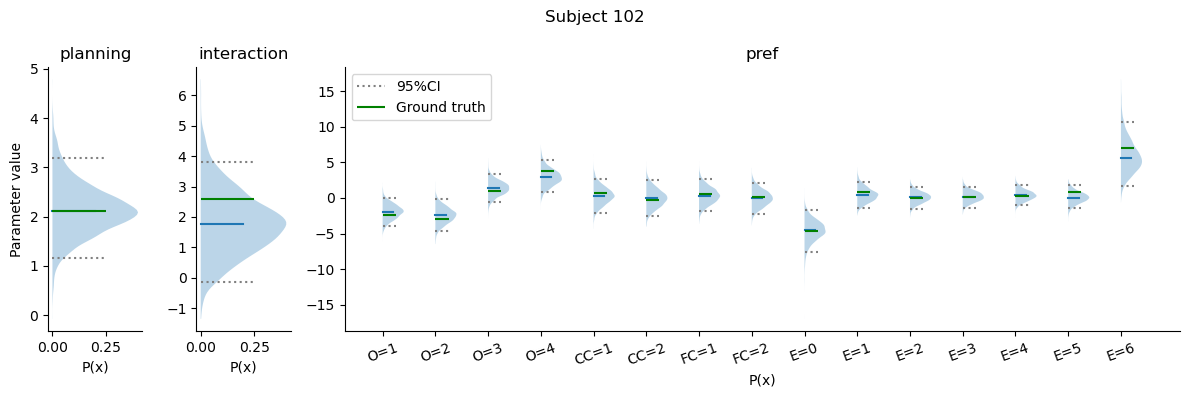

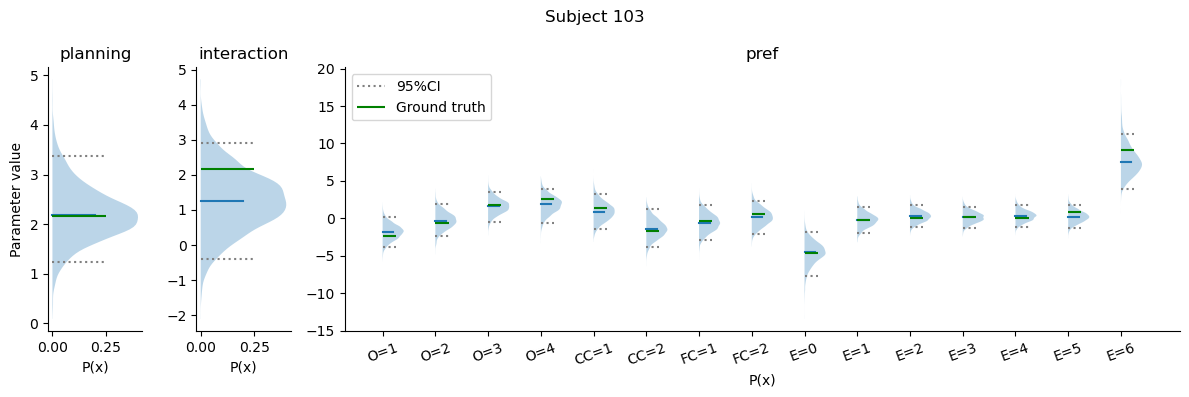

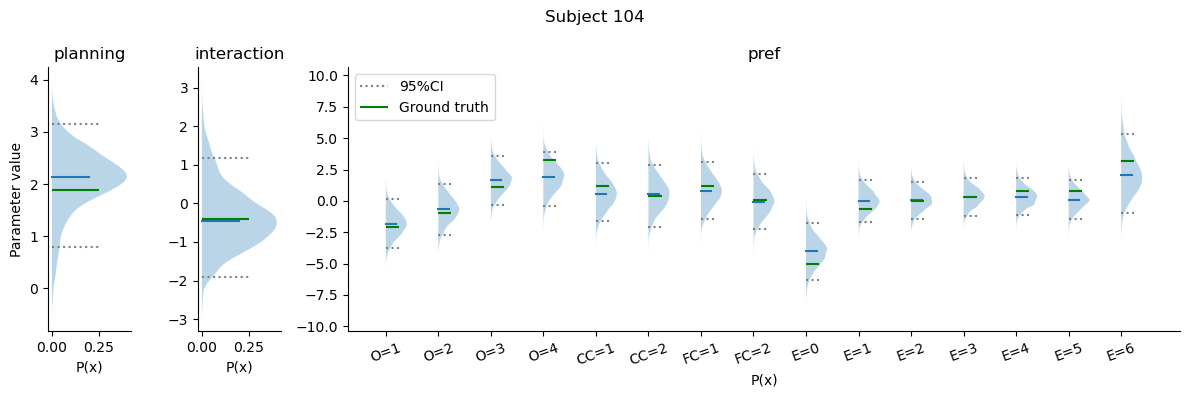

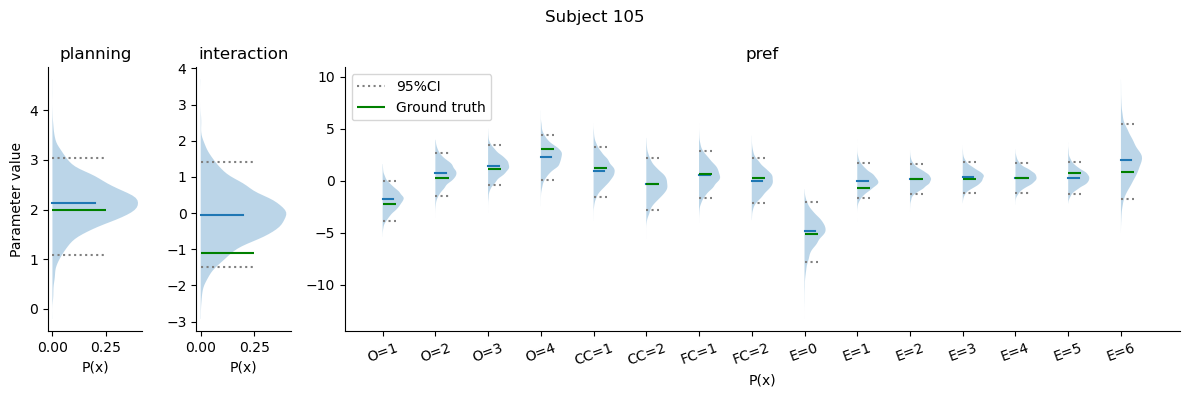

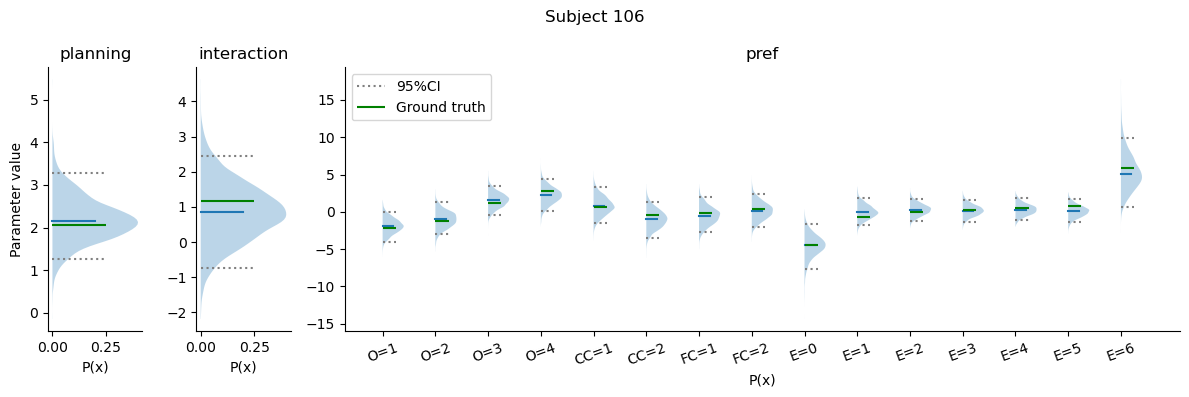

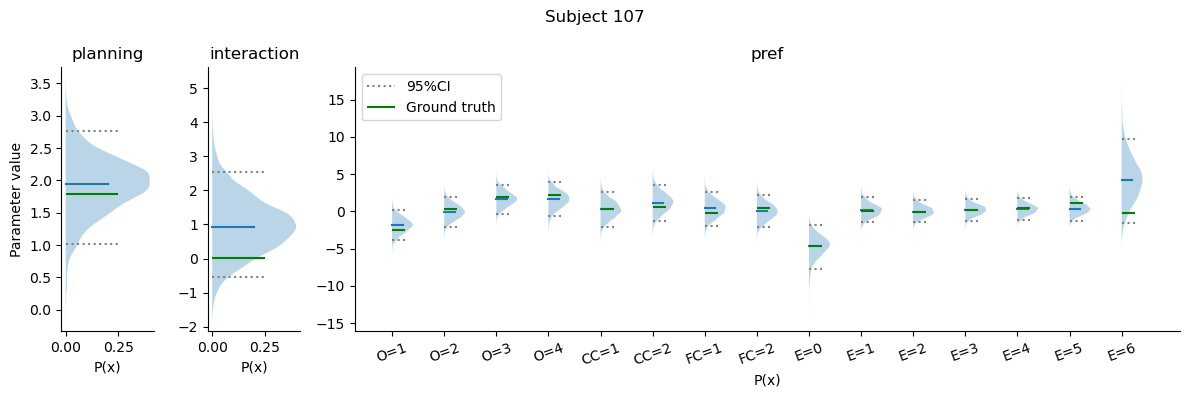

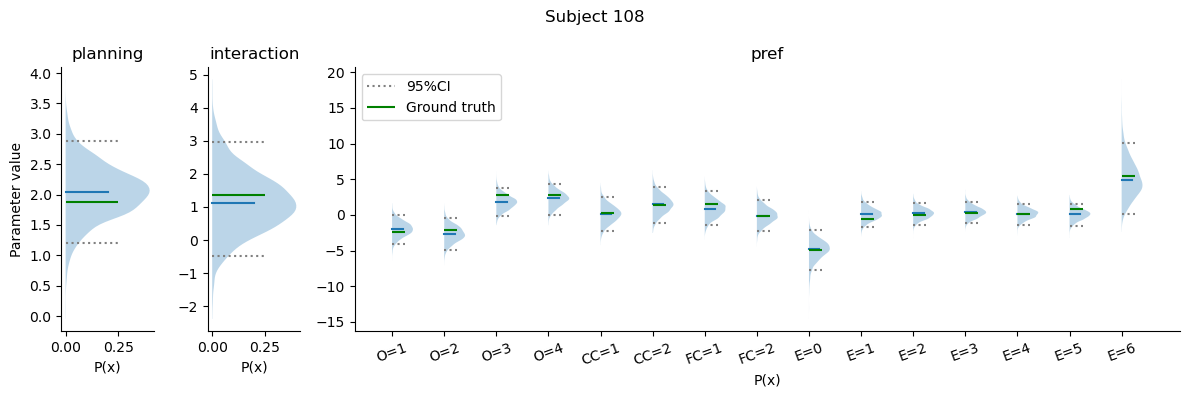

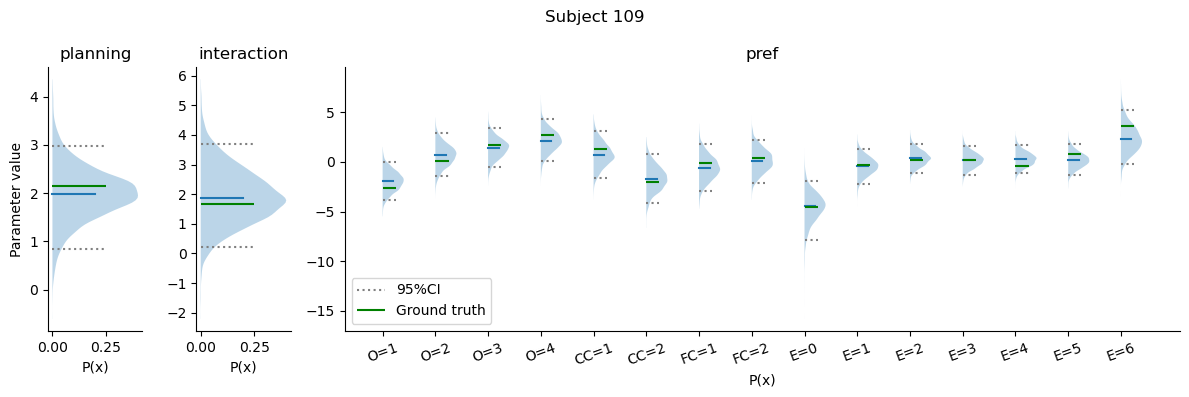

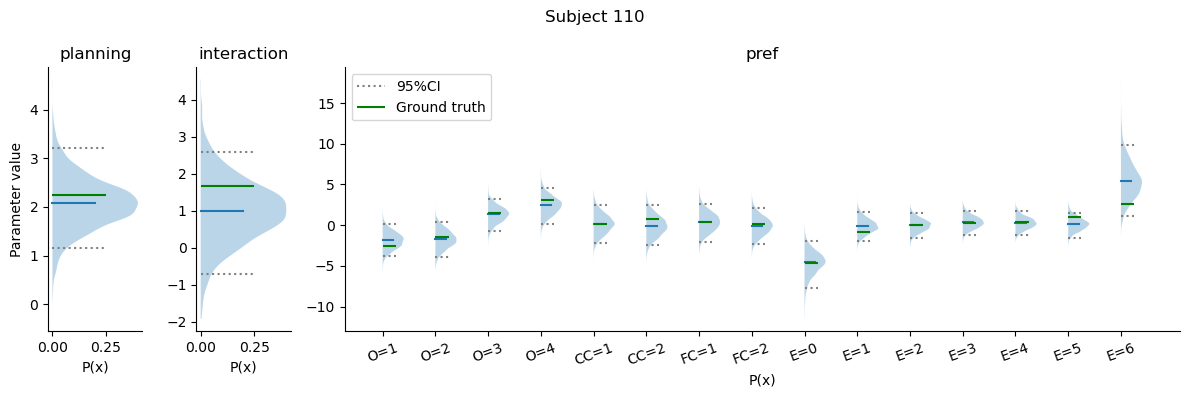

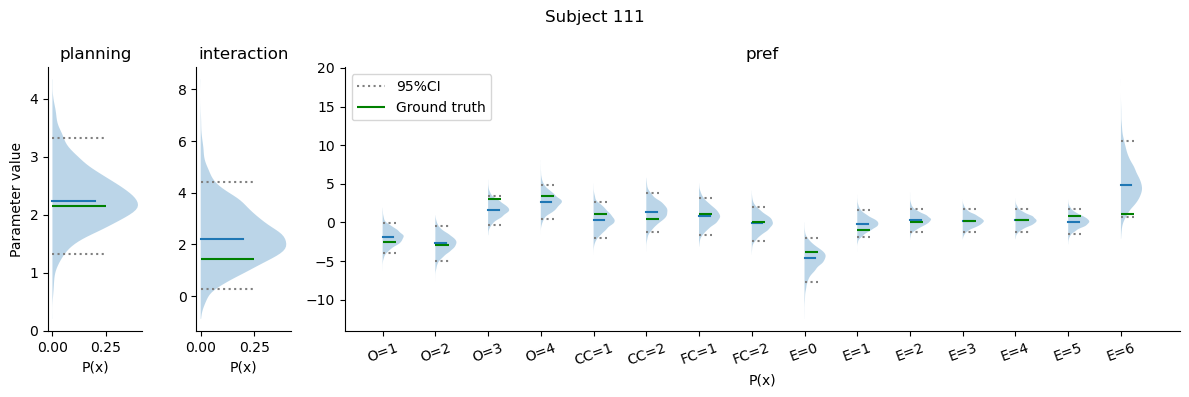

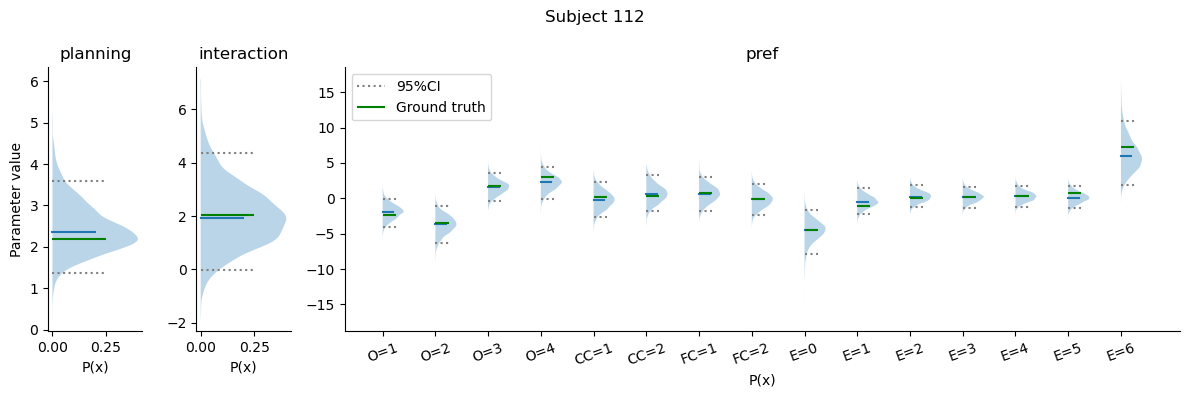

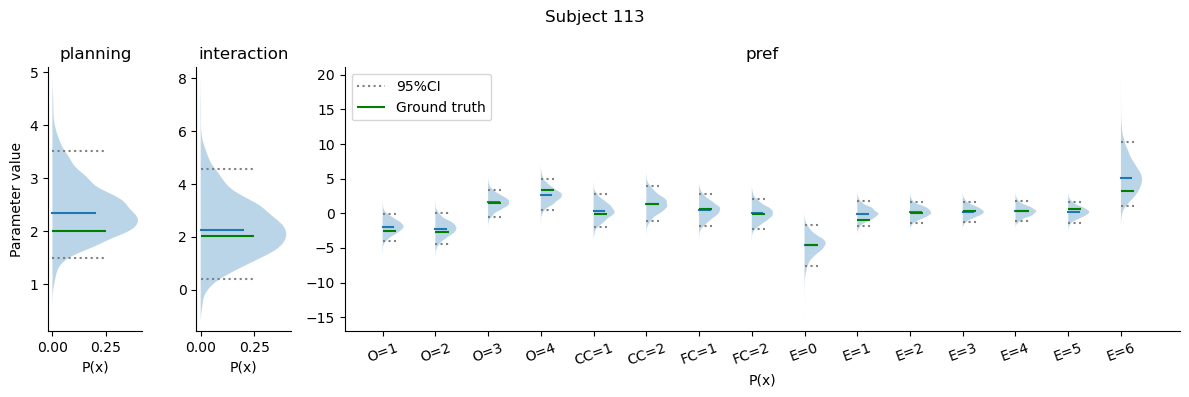

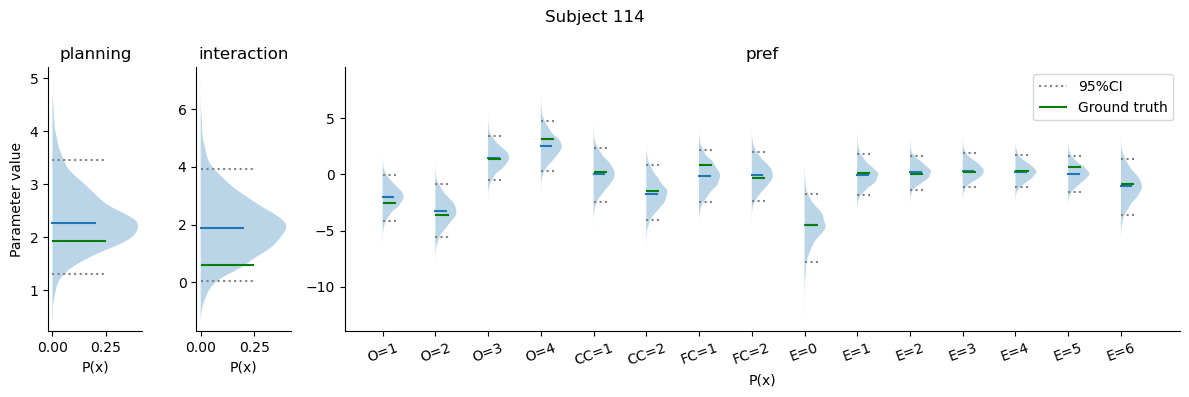

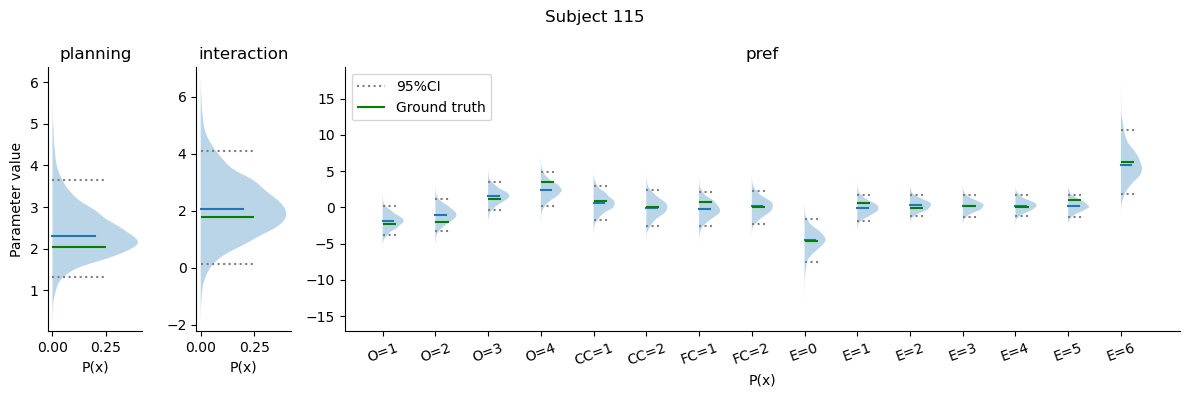

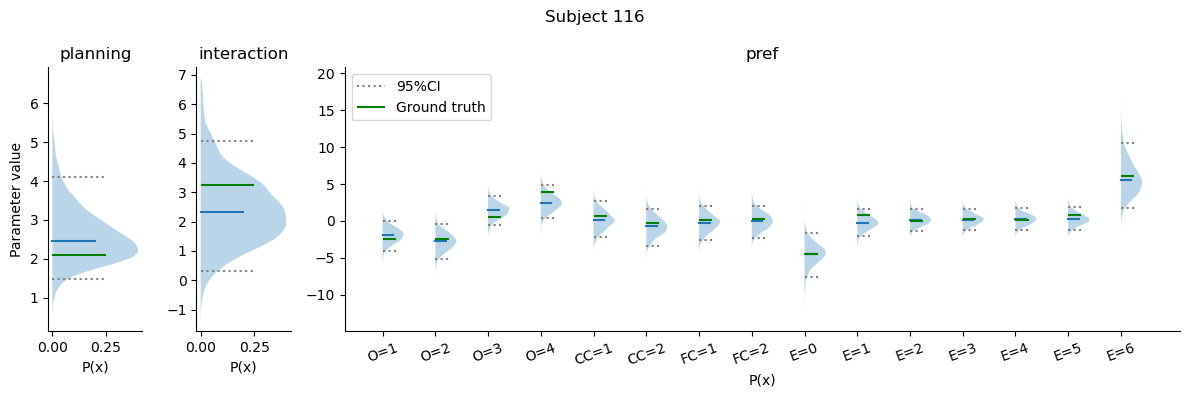

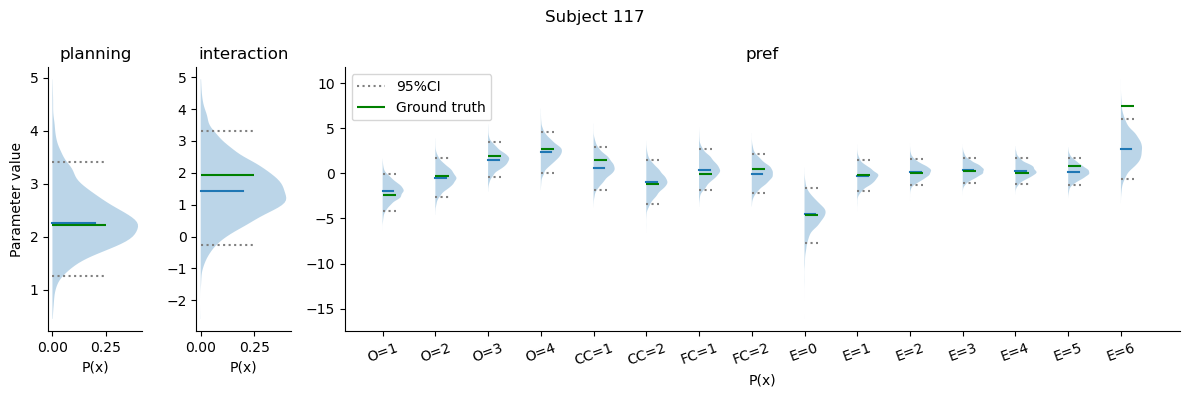

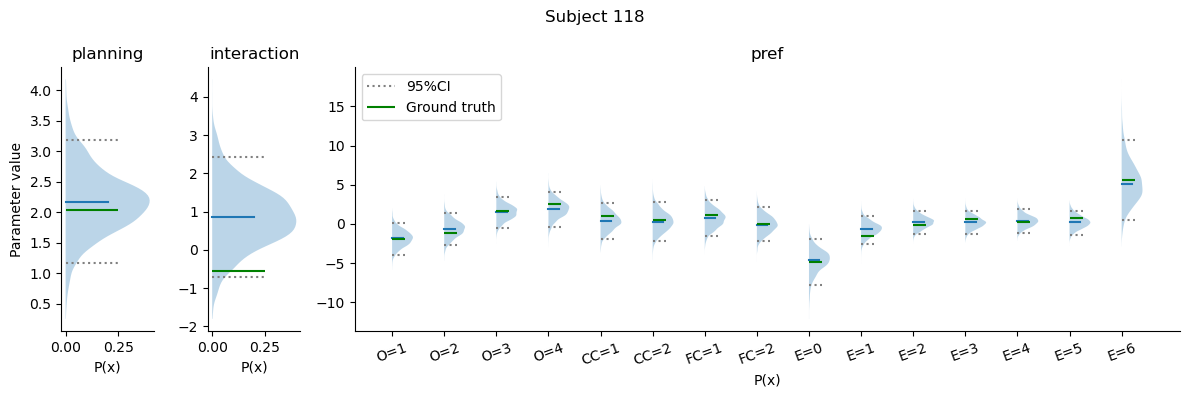

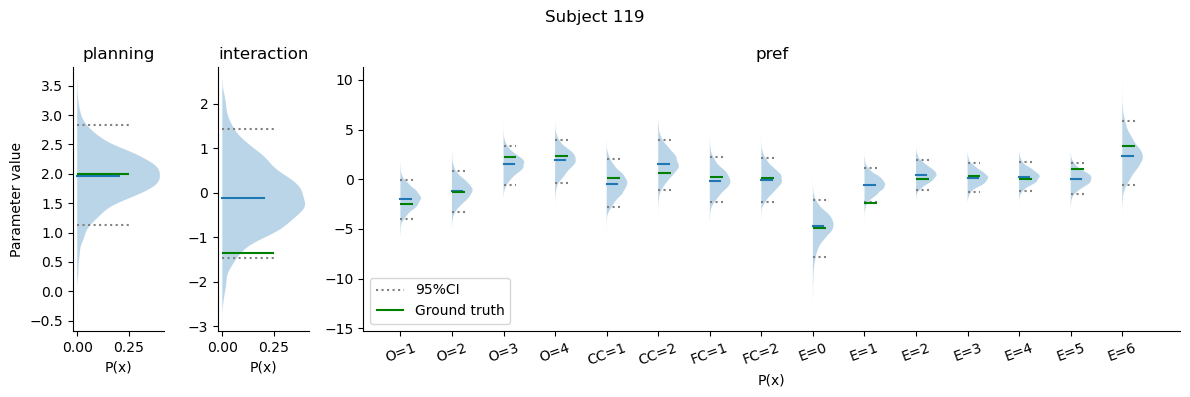

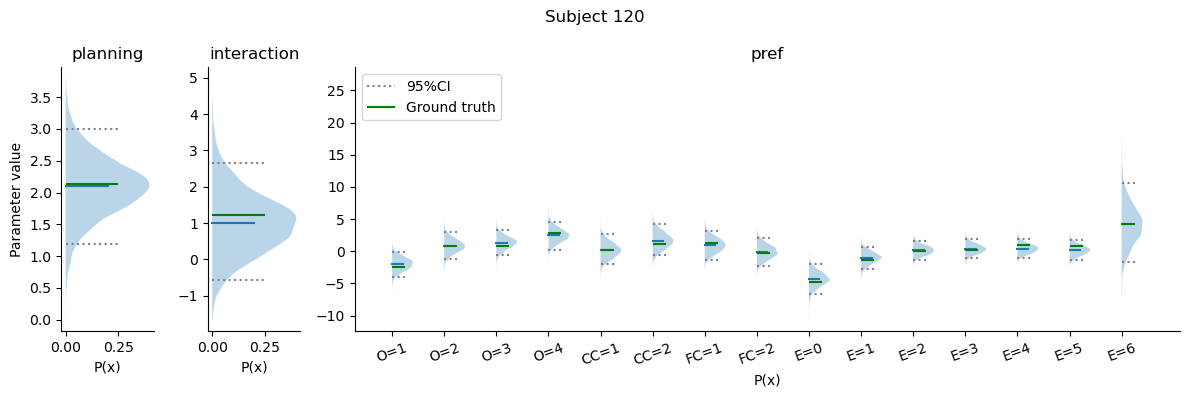

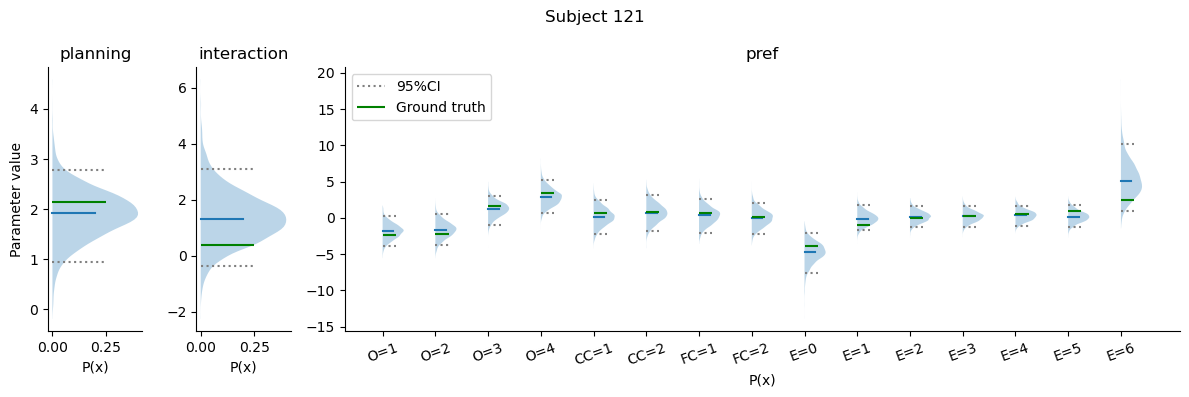

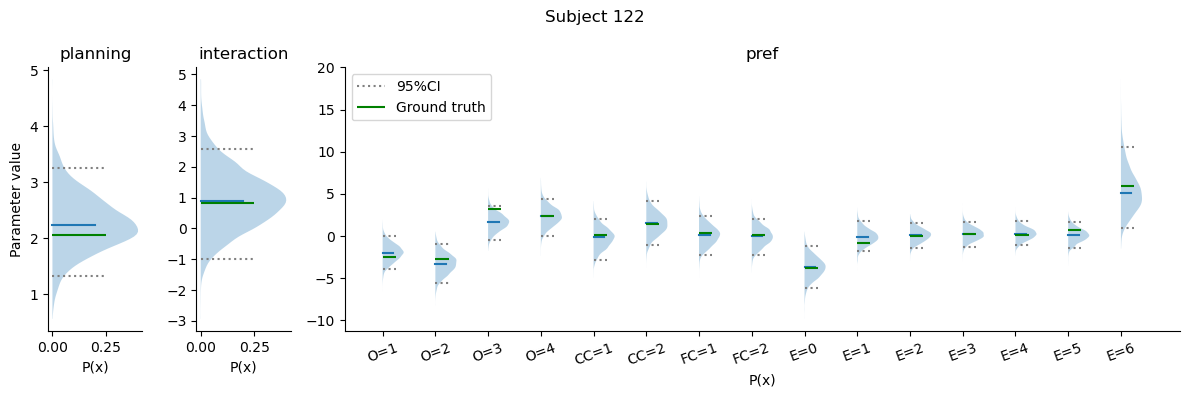

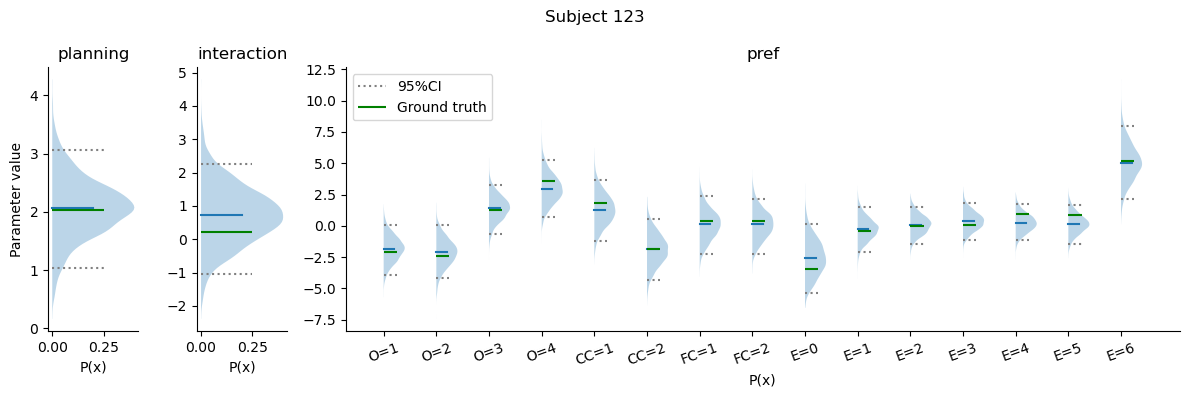

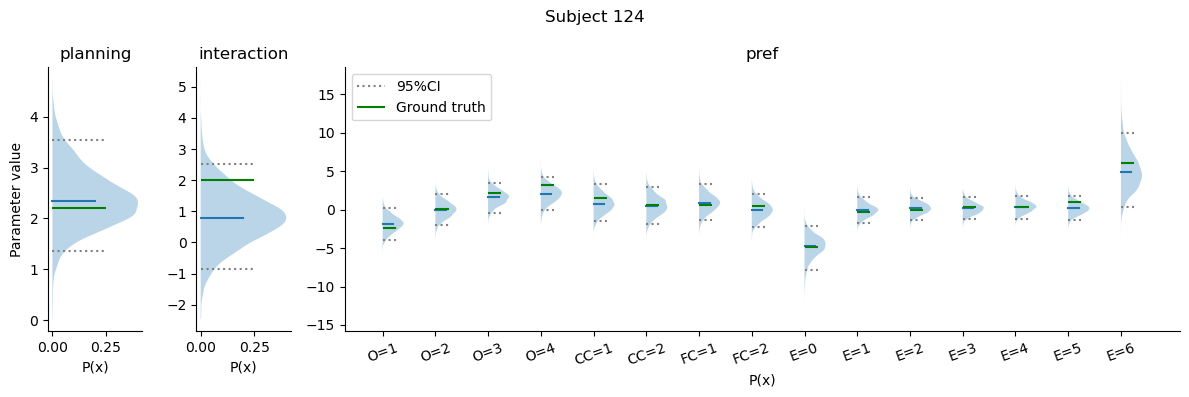

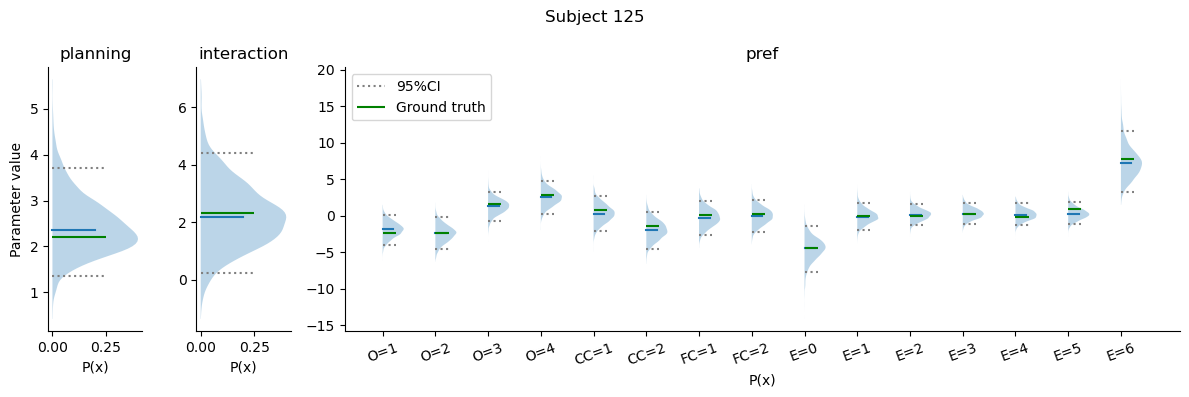

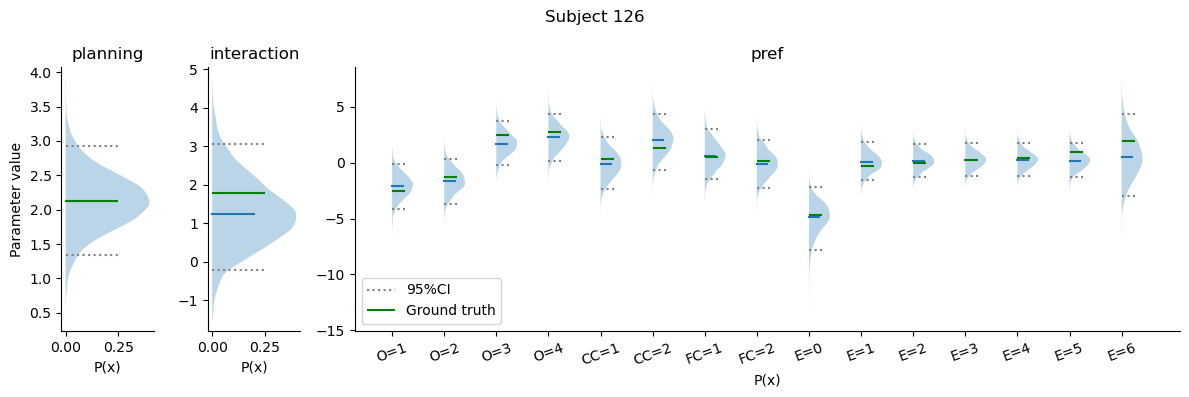

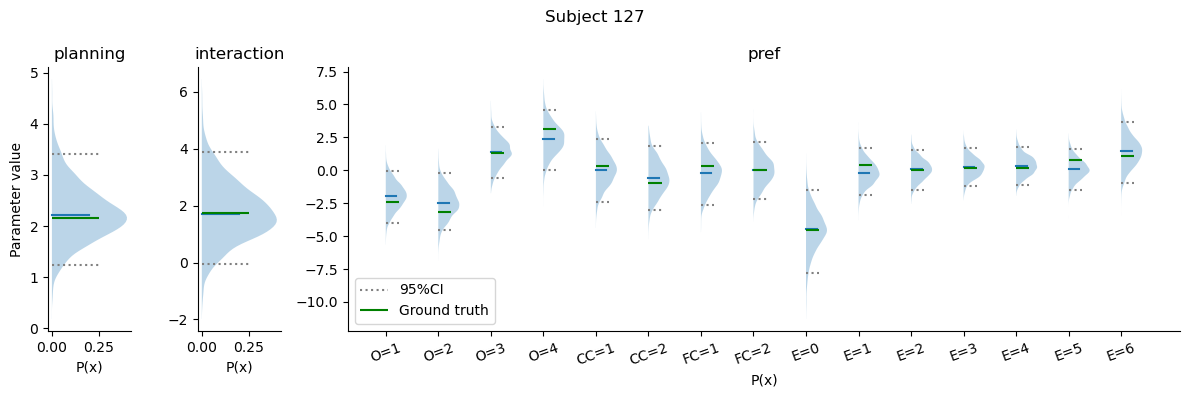

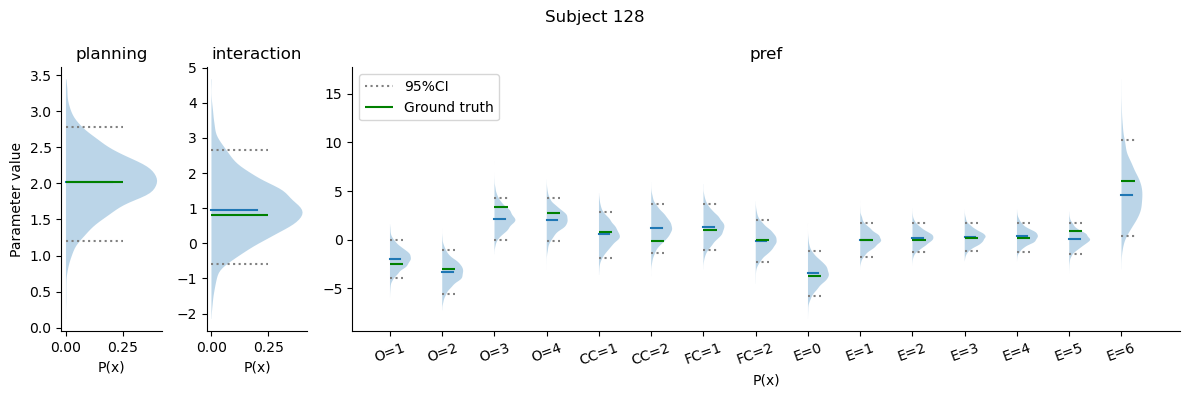

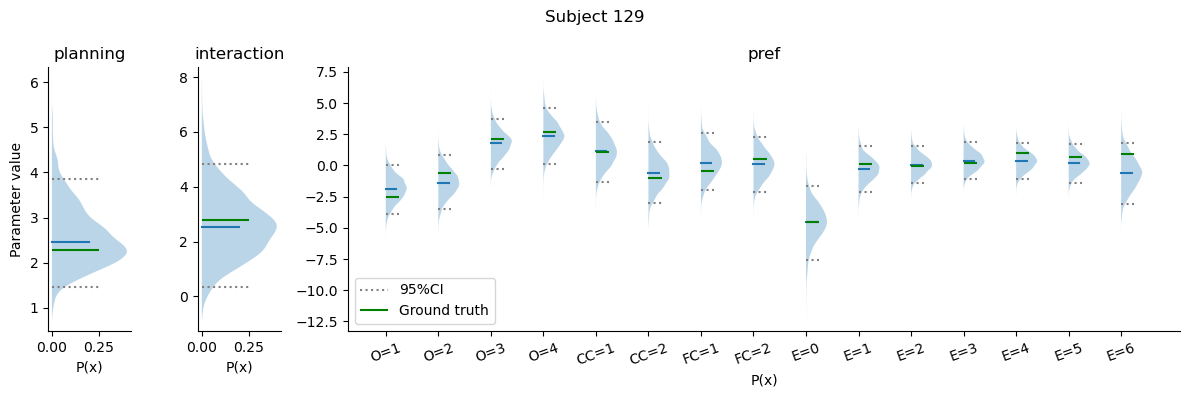

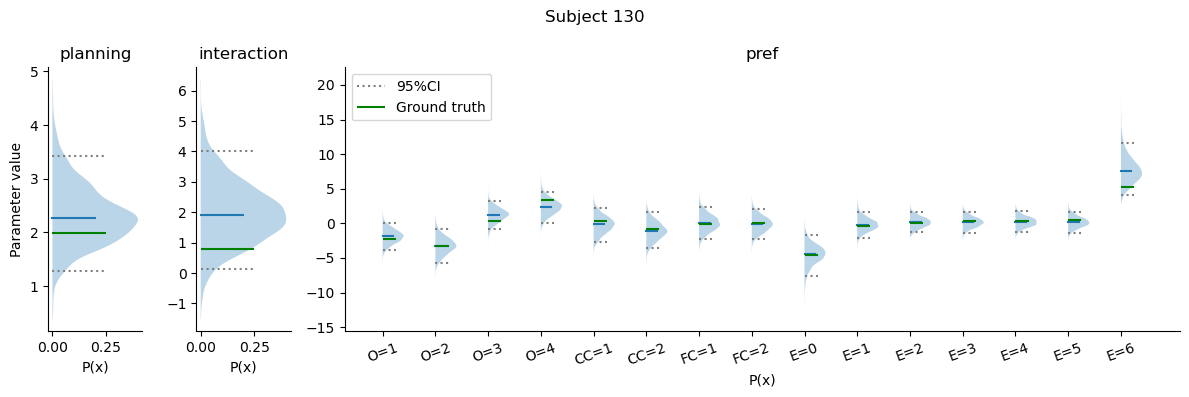

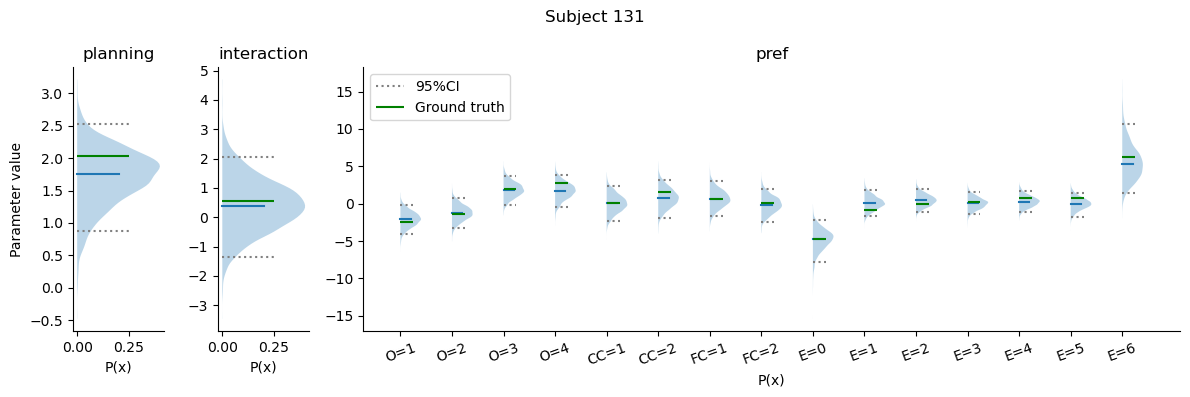

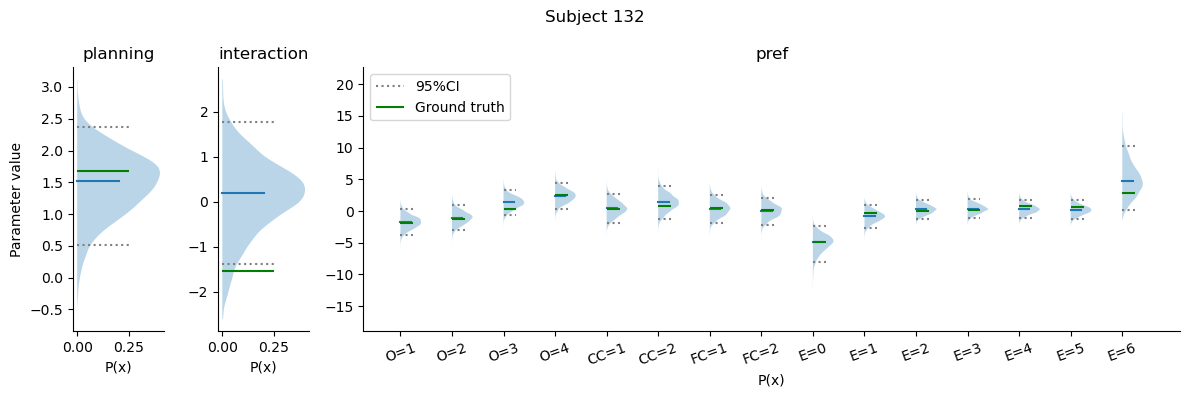

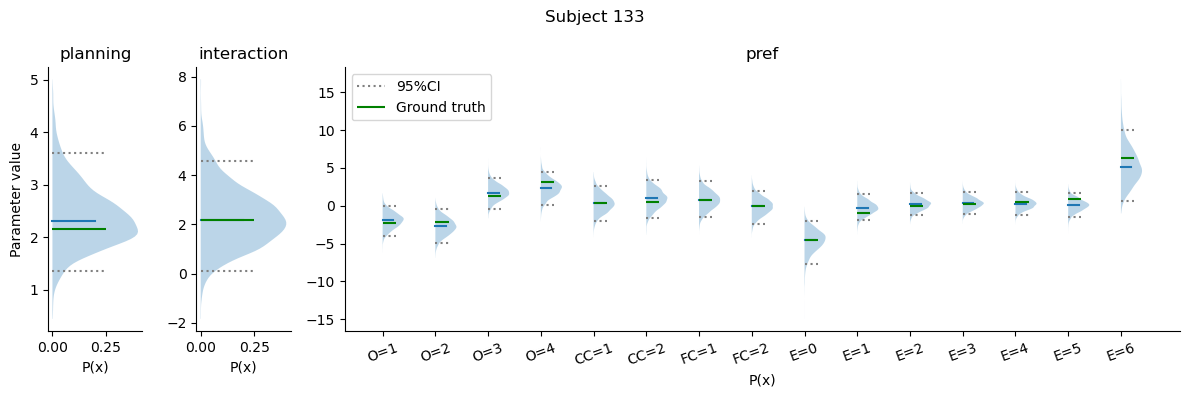

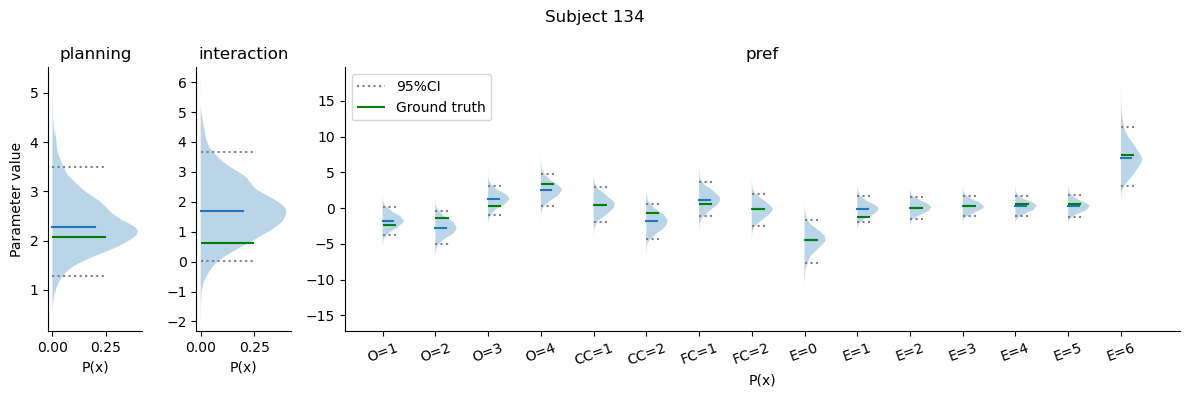

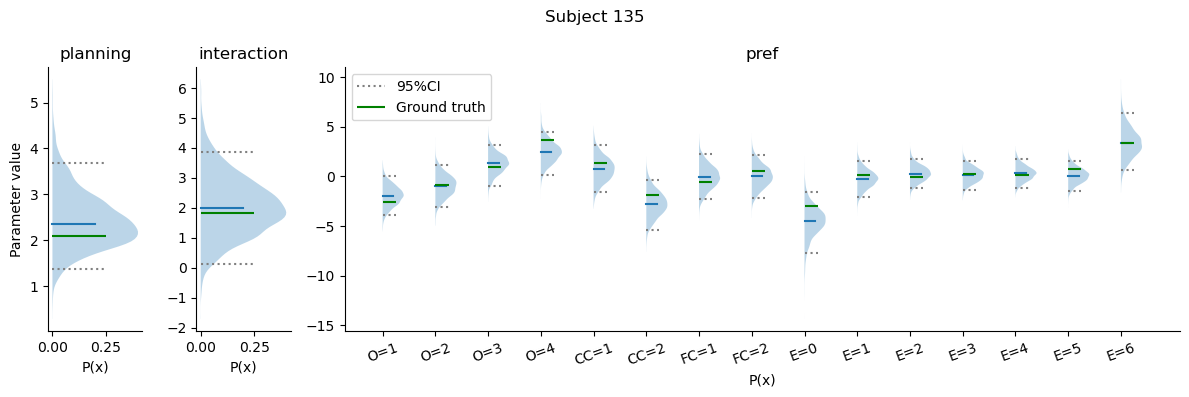

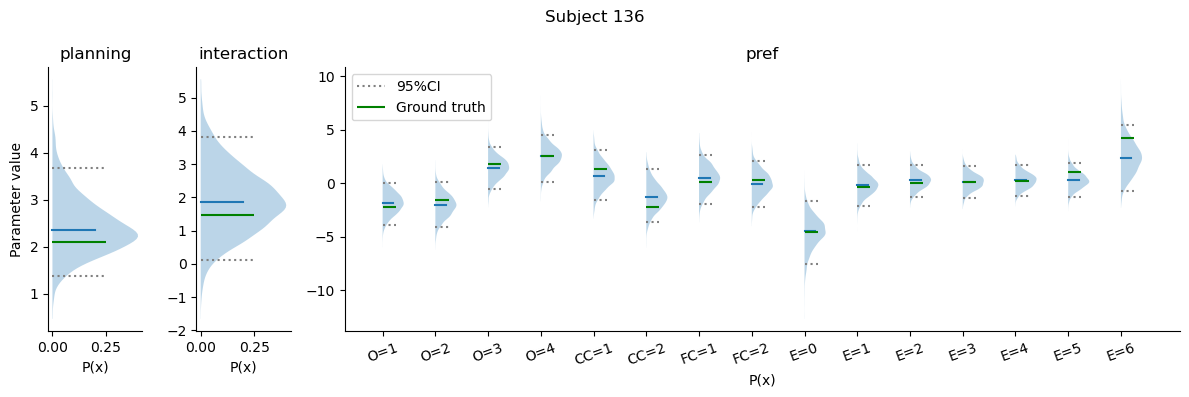

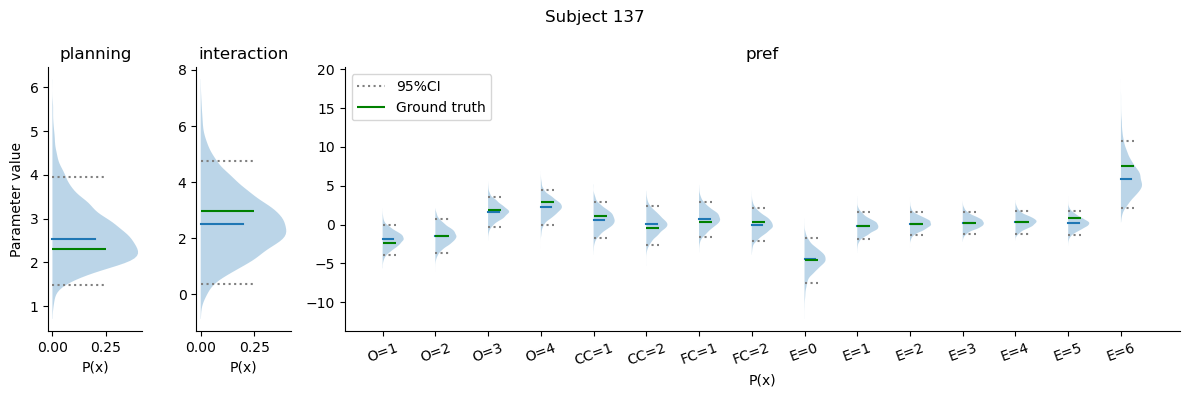

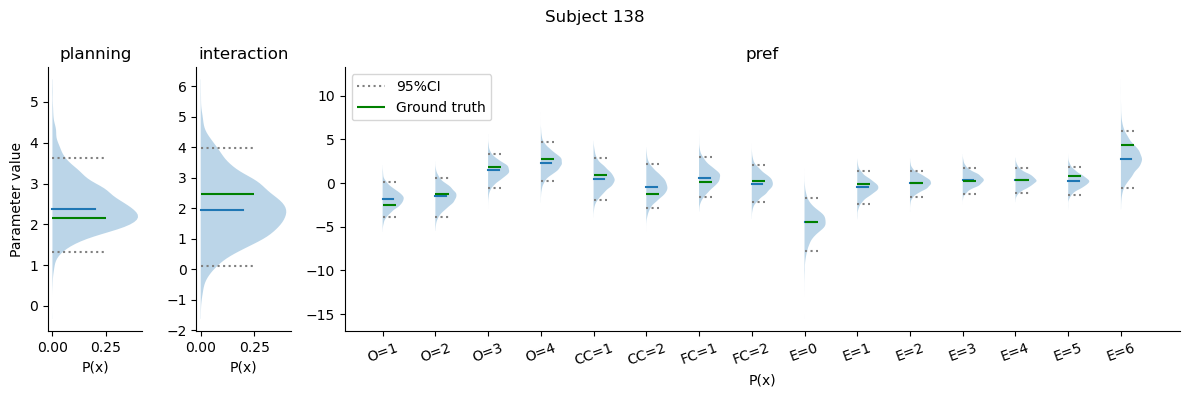

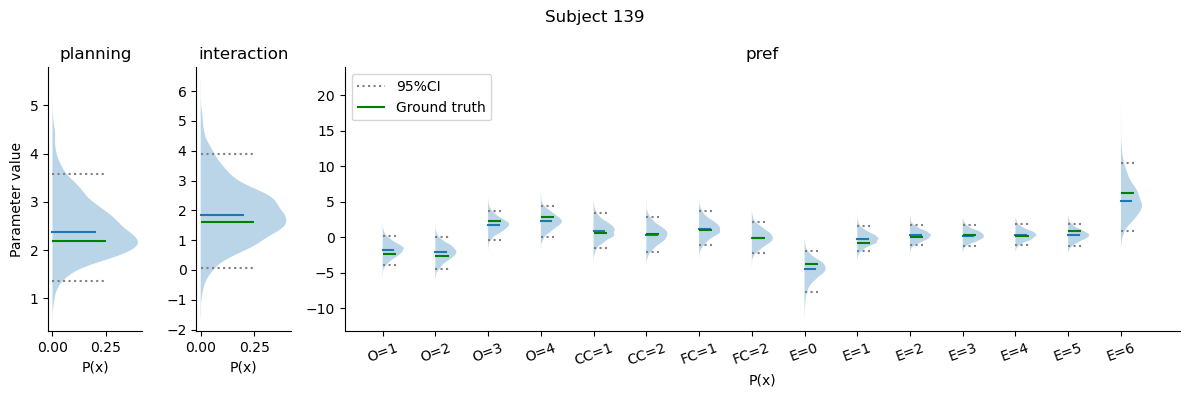

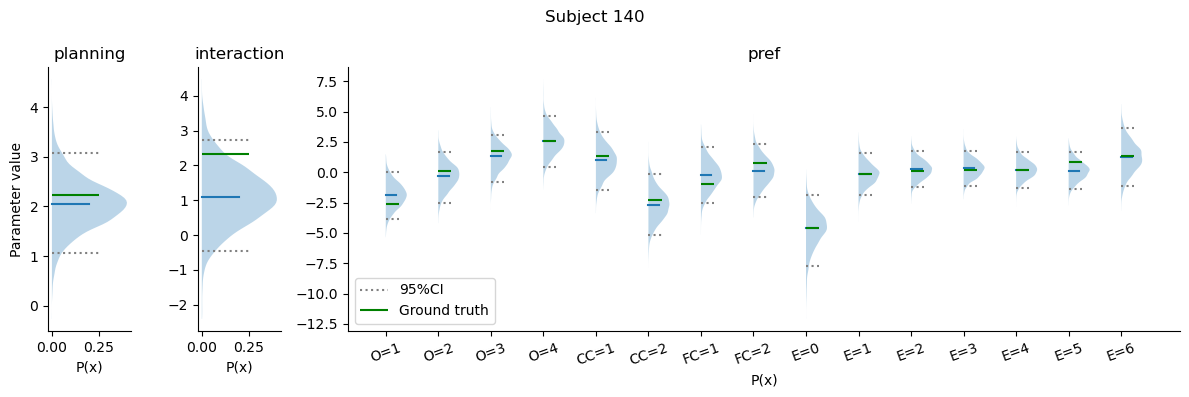

In [5]:
#| label: suppfig-single_subject_parameter_recovery
#| fig-cap: "Single subjects parameters recovery"
#| layout-ncol: 2
# Loop through each subject:
for i, sub in enumerate(beh_data["vpn"].unique()):
    fig, ax = plt.subplot_mosaic("ABCCCCCC", figsize=(12, 4))
    fig_key = ["A", "B", "C"]
    for ii, param in enumerate(["beta_planning", "beta_interaction", "beta_pref"]):
        # Plot parameters fitted to the simulated data:
        posterior_sim = idata.posterior[param + "_sub"].values[:, :, i, :].reshape(-1, idata_orig.posterior[param].shape[-1])
        ax[fig_key[ii]].violinplot(posterior_sim, positions=range(posterior_sim.shape[-1]), widths=0.8,
                        showmeans=False, showmedians=True,
                        showextrema=False, side="high");
        # Get 95% CI and plot it:
        if len(np.squeeze(posterior_sim).shape) == 1:
            ci = az.hdi(posterior_sim)[0]
            ax[fig_key[ii]].hlines(ci, 
                            xmin=[iii for iii in range(posterior_sim.shape[-1])], 
                            xmax=[iii+0.25 for iii in range(posterior_sim.shape[-1])], 
                            color="grey", linestyle=':', label="95%CI")
        else:
            for iii, reg in enumerate(range(posterior_sim.shape[1])):
                ci = az.hdi(posterior_sim[:, reg])
                if iii == 0:
                    ax[fig_key[ii]].hlines(ci, 
                                        xmin=iii, 
                                        xmax=iii+0.25,
                                        color="grey", linestyle=':', label="95%CI")
                else:
                    ax[fig_key[ii]].hlines(ci, 
                        xmin=iii, 
                        xmax=iii+0.25,
                        color="grey", linestyle=':')
        # Plot the ground truth parameter:
        ax[fig_key[ii]].hlines(ground_truth_params[param][i], 
                               xmin=[iii for iii in range(posterior_sim.shape[-1])], 
                               xmax=[iii+0.25 for iii in range(posterior_sim.shape[-1])], 
                               color="green", label="Ground truth")
        ax[fig_key[ii]].set_title(param.split("_")[1])
        ax[fig_key[ii]].spines[['right', 'top']].set_visible(False)
        ax[fig_key[ii]].set_xlabel("P(x)")
        if ii == 0:
            ax[fig_key[ii]].set_ylabel("Parameter value")
        elif ii == 2:
            ax[fig_key[ii]].legend()
        if param == "beta_pref":
            ax[fig_key[ii]].set_xticks(range(posterior_sim.shape[-1]))
            ax[fig_key[ii]].set_xticklabels(["O=1", "O=2", "O=3", "O=4", 
                                        "CC=1", "CC=2", 
                                        "FC=1", "FC=2",
                                        "E=0", "E=1", "E=2", "E=3", "E=4", "E=5", "E=6"], 
                                        rotation=20)
        plt.suptitle(f"Subject {sub}")
    plt.tight_layout()
    plt.show()

Across all participants, the ground truth parameters is well within the credible intervals of the retrieved parameters from the data, indicating that our model is indeed capable of recovering the parameters of the underlying generative model.